# TEAM DYNAMO (GROUP 14)- TECHCRUSH CAPSTONE PROJECT

# Retail / Marketing: Customer Purchase Prediction

In [4]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

#EDA
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
# Cell: Import Modeling Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve, confusion_matrix,
                              classification_report)


# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## 1. DATA UNDERSTANDING

In [5]:
from google.colab import drive
drive.mount('/content/drive')

# import from a loca server

df = pd.read_csv("/content/drive/MyDrive/Team Dynamo/online_shoppers_intention.csv")

df

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


In [6]:
# import from a loca server

#df = pd.read_csv(r"C:\Users\Johnson Samuel D\Desktop\TechCrush\Team Dynamo(working folder)\online_shoppers_intention_1.csv")

#df

In [7]:
df.shape

(12330, 18)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [9]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [10]:
df.tail()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False
12329,0,0.0,0,0.0,3,21.250000,0.000000,0.066667,0.000000,0.0,Nov,3,2,1,2,New_Visitor,True,False


In [11]:
df.sample(20)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
4332,4,160.583333,1,136.75,21,1632.733333,0.000000,0.004545,16.539091,0.0,May,2,2,4,2,New_Visitor,True,False
8030,1,49.500000,0,0.00,65,3804.287500,0.000000,0.020313,0.000000,0.0,Nov,2,5,3,13,Returning_Visitor,True,False
4894,0,0.000000,1,5.00,10,649.500000,0.000000,0.020000,0.000000,0.0,May,2,2,1,2,Returning_Visitor,False,False
6879,0,0.000000,0,0.00,9,145.900000,0.022222,0.074074,0.000000,0.0,June,1,1,2,3,Returning_Visitor,True,False
10245,12,209.375000,0,0.00,43,2754.117424,0.004687,0.033875,13.681089,0.0,Dec,3,2,3,2,Returning_Visitor,False,False
12275,0,0.000000,0,0.00,20,2001.833333,0.009524,0.013492,0.000000,0.0,Nov,2,2,9,6,Returning_Visitor,False,False
11179,1,9.000000,0,0.00,13,858.833333,0.014286,0.051190,0.000000,0.0,Nov,1,1,6,11,Returning_Visitor,False,True
6511,3,98.100000,2,28.20,130,4994.848002,0.019799,0.036826,0.000000,0.0,Sep,2,2,4,1,Returning_Visitor,True,False
9767,0,0.000000,0,0.00,64,2264.091667,0.006250,0.008854,0.000000,0.0,Nov,1,1,3,10,Returning_Visitor,False,False
6084,0,0.000000,0,0.00,4,43.200000,0.000000,0.050000,0.000000,0.0,Jul,3,2,4,3,Returning_Visitor,False,False


In [12]:
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

In [13]:
## checking for null values
df.isna().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [14]:
## Checking for duplicates

df.duplicated().sum()

np.int64(125)

## 2. Exploratory Data Analysis (EDA)

### Univariate analysis
1. Target Distribution
2. Numerical Feature Distribution

In [15]:
# Checking for the distribution

df['Revenue'].value_counts(normalize=True).to_frame(name='Count')

,Count
Revenue,
False,0.845255
True,0.154745


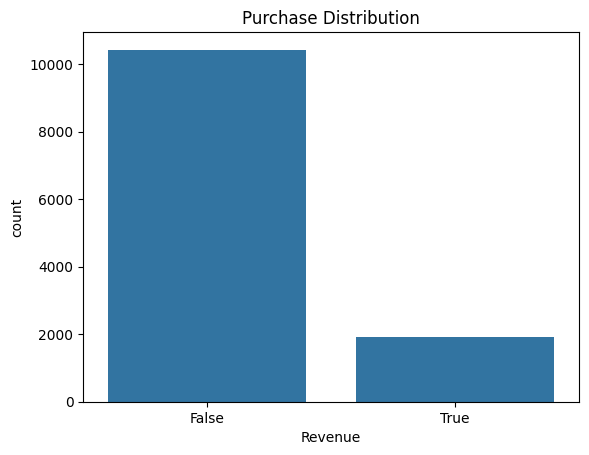

In [16]:
sns.countplot(x='Revenue', data=df)
plt.title("Purchase Distribution")

plt.savefig('purchase_distribution.png')
plt.show()


In [17]:
numeric_cols = ['Administrative', 'Administrative_Duration','Informational', 'Informational_Duration','ProductRelated', 'ProductRelated_Duration','BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

numeric_cols

['Administrative',
 'Administrative_Duration',
 'Informational',
 'Informational_Duration',
 'ProductRelated',
 'ProductRelated_Duration',
 'BounceRates',
 'ExitRates',
 'PageValues',
 'SpecialDay']

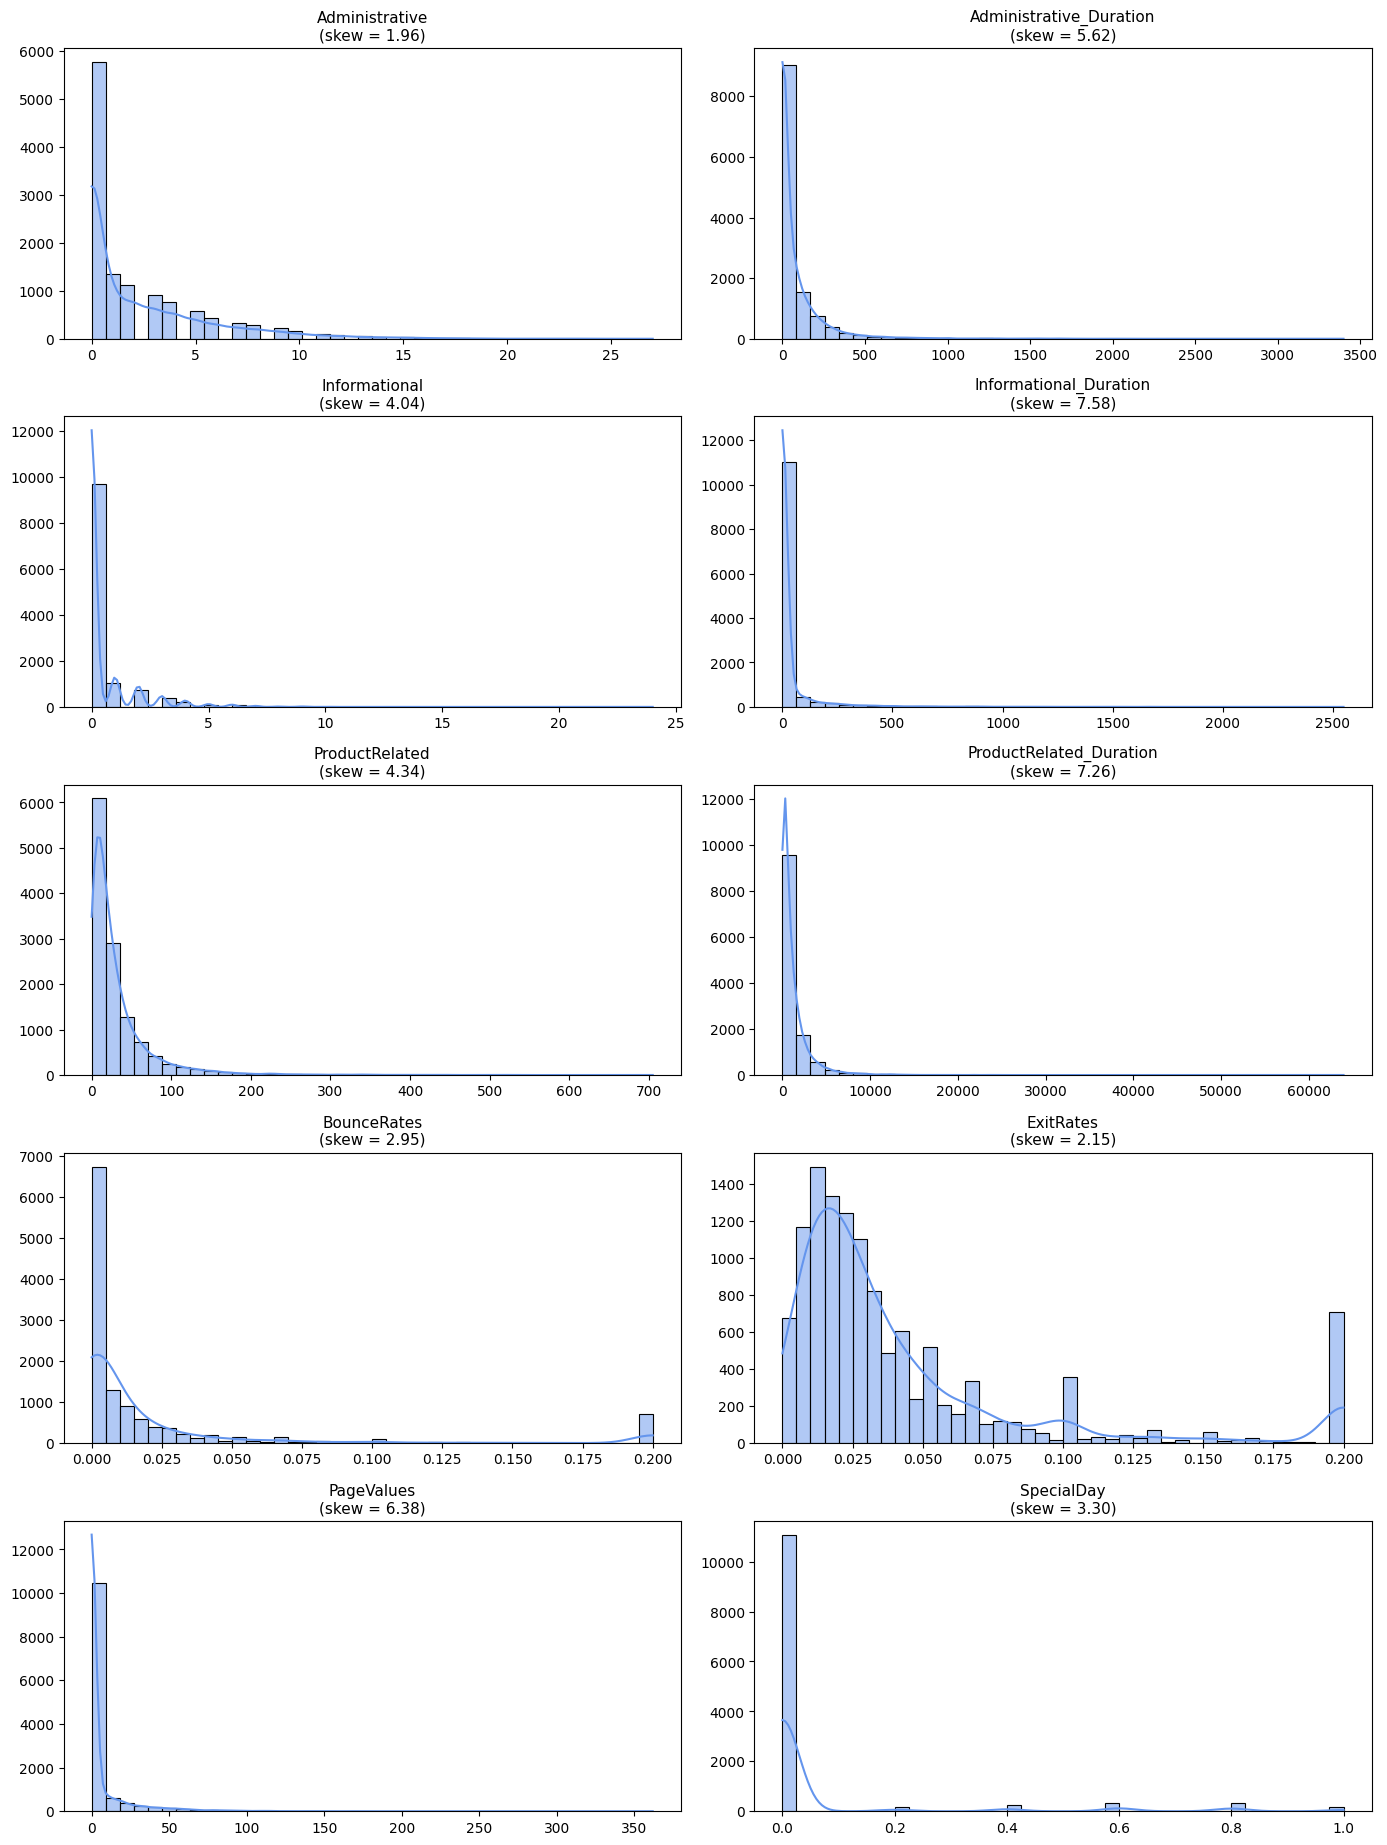

In [18]:
# Histogram and Density Plots


fig, axes = plt.subplots(len(numeric_cols)//2 + 1, 2, figsize=(14, 2.2 * len(numeric_cols)))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='cornflowerblue', bins=40)
    axes[i].set_title(f'{col}\n(skew = {df[col].skew():.2f})', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('numeric_distribution.png')
plt.show()

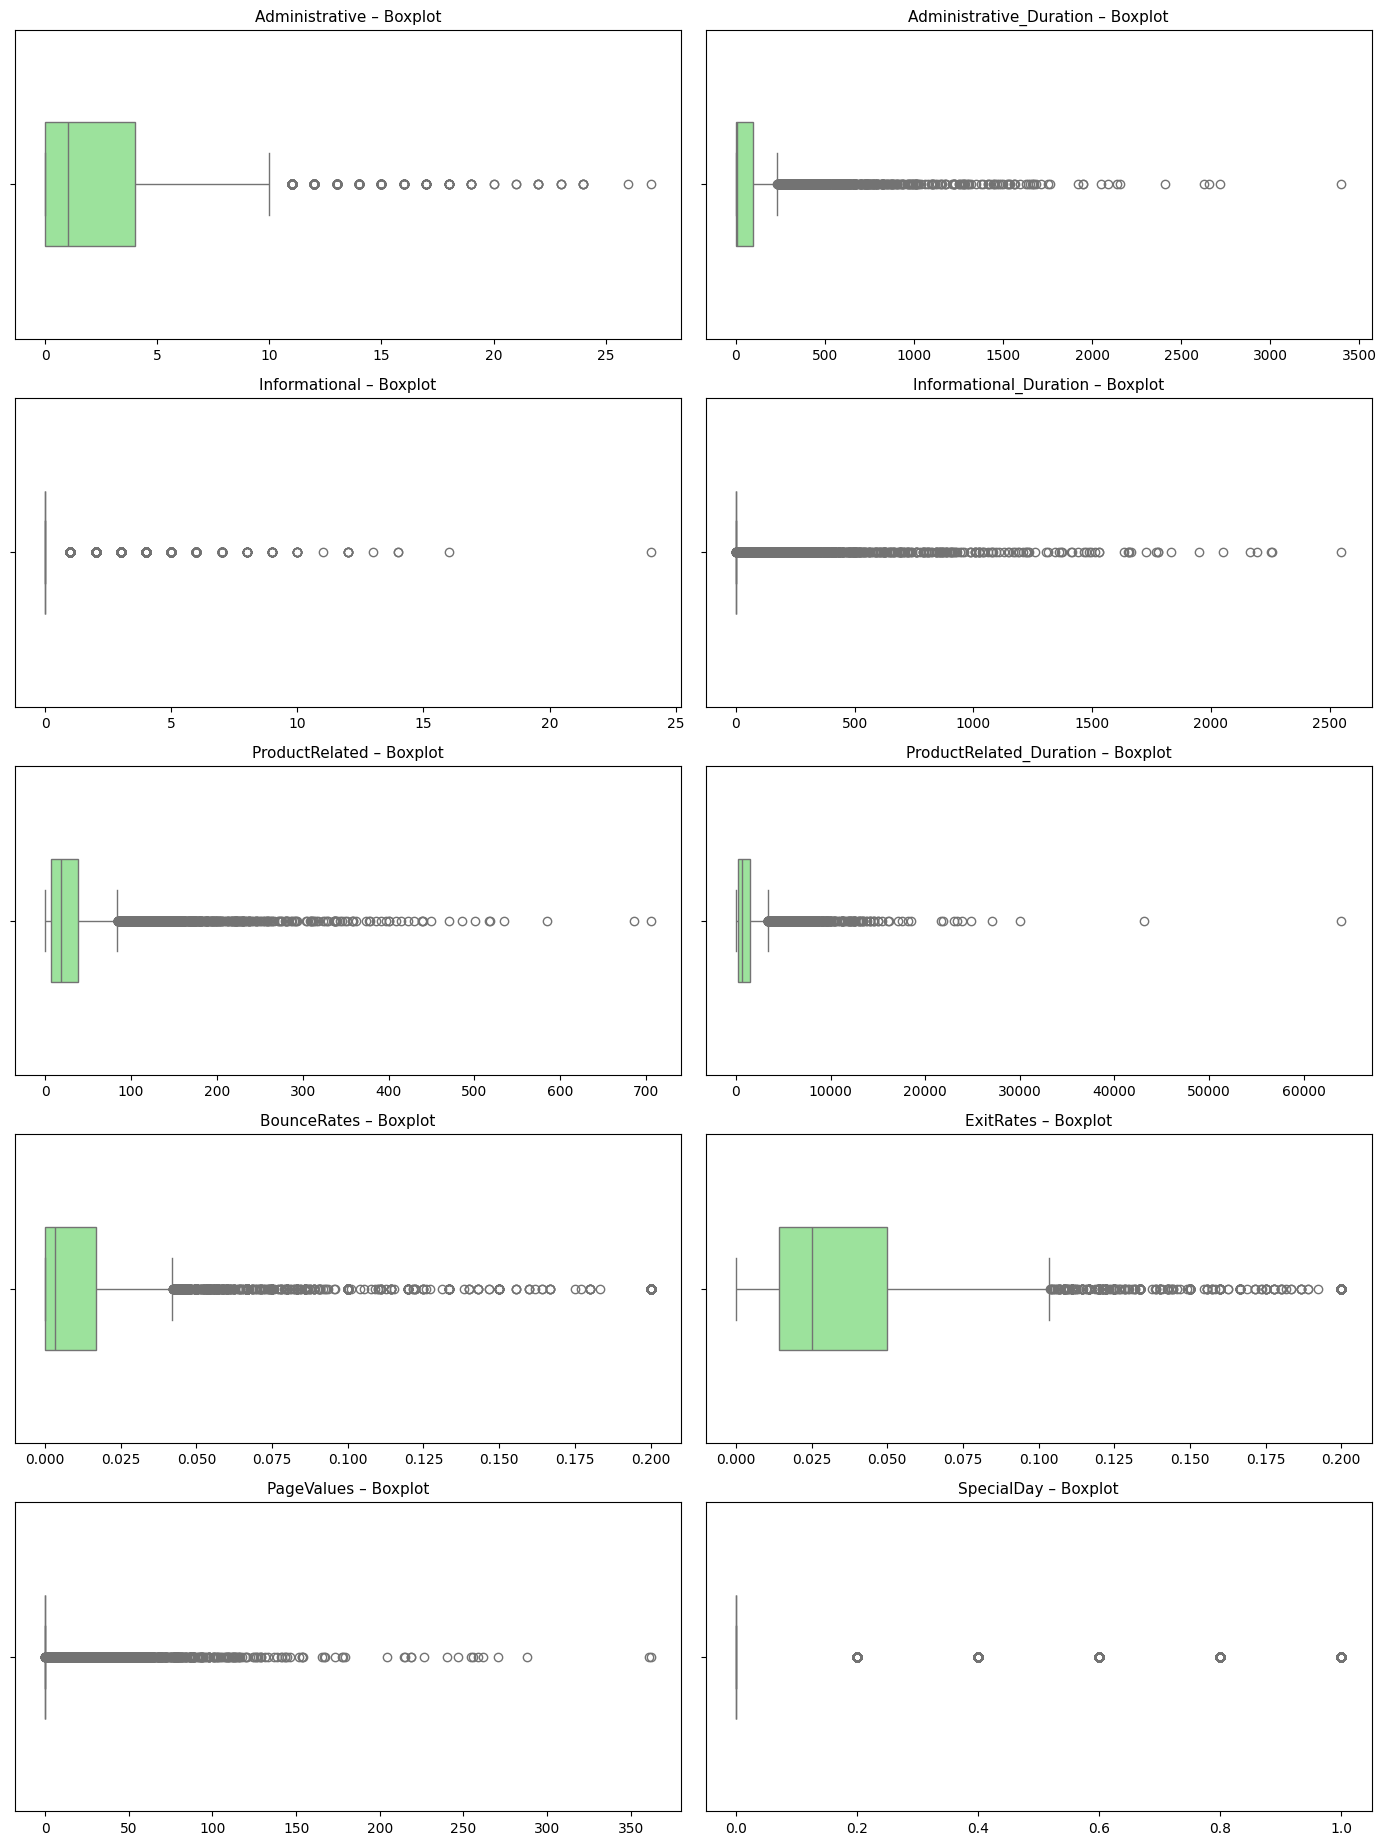

In [19]:
# Outliers Detection


fig, axes = plt.subplots(len(numeric_cols)//2 + 1, 2, figsize=(14, 2.2 * len(numeric_cols)))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='lightgreen', width=0.4)
    axes[i].set_title(f'{col} – Boxplot', fontsize=11)
    axes[i].set_xlabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [20]:
# Summary of outliers in colums

outliers_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct_out = count_out / len(df) * 100
    outliers_summary.append([col, count_out, f"{pct_out:.2f}%", f"[{lower:.2f}, {upper:.2f}]"])

out_online_shoppers = pd.DataFrame(outliers_summary, columns=['Variable', 'Outliers', '% Outliers', 'IQR Bounds'])
print(out_online_shoppers.sort_values('% Outliers', ascending=False).to_string(index=False))

               Variable  Outliers % Outliers          IQR Bounds
Administrative_Duration      1172      9.51%   [-139.88, 233.14]
              ExitRates      1099      8.91%       [-0.04, 0.10]
         ProductRelated       987      8.00%     [-39.50, 84.50]
ProductRelated_Duration       961      7.79% [-1735.89, 3384.19]
         Administrative       404      3.28%      [-6.00, 10.00]
             PageValues      2730     22.14%        [0.00, 0.00]
          Informational      2631     21.34%        [0.00, 0.00]
 Informational_Duration      2405     19.51%        [0.00, 0.00]
            BounceRates      1551     12.58%       [-0.03, 0.04]
             SpecialDay      1251     10.15%        [0.00, 0.00]


In [21]:
categorical_cols = ['Month', 'OperatingSystems', 'Browser', 'Region','TrafficType', 'VisitorType', 'Weekend']

categorical_cols

['Month',
 'OperatingSystems',
 'Browser',
 'Region',
 'TrafficType',
 'VisitorType',
 'Weekend']

In [22]:
# Checking for frequency distriution for numerical columns

for col in categorical_cols:
    freq = df[col].value_counts(dropna=False).to_frame(name='Count')
    freq['%'] = (freq['Count'] / len(df) * 100).round(2)
    print(freq.head(12))
    if len(freq) > 12:
        print(f" + {len(freq)-12} more categories\n")

       Count      %
Month              
May     3364  27.28
Nov     2998  24.31
Mar     1907  15.47
Dec     1727  14.01
Oct      549   4.45
Sep      448   3.63
Aug      433   3.51
Jul      432   3.50
June     288   2.34
Feb      184   1.49
                  Count      %
OperatingSystems              
2                  6601  53.54
1                  2585  20.97
3                  2555  20.72
4                   478   3.88
8                    79   0.64
6                    19   0.15
7                     7   0.06
5                     6   0.05
         Count      %
Browser              
2         7961  64.57
1         2462  19.97
4          736   5.97
5          467   3.79
6          174   1.41
10         163   1.32
8          135   1.09
3          105   0.85
13          61   0.49
7           49   0.40
12          10   0.08
11           6   0.05
 + 1 more categories

        Count      %
Region              
1        4780  38.77
3        2403  19.49
4        1182   9.59
2        1136  

## Bivariate analysis
1. Revenue vs key behaviour metrics (e.g pagevalues,bouncerates, exitrates)

In [23]:
# Key Numerical values we are considering are:

key_numerics = ['ProductRelated_Duration', 'BounceRates', 'ExitRates','PageValues', 'Administrative_Duration', 'Informational_Duration']

key_numerics

['ProductRelated_Duration',
 'BounceRates',
 'ExitRates',
 'PageValues',
 'Administrative_Duration',
 'Informational_Duration']

In [24]:
# Mean comparison table

means = df.groupby('Revenue')[key_numerics].mean().round(3)
means.index = means.index.map({False: 'No Purchase', True: 'Purchase'})
means = means.T
means['Difference (Purchase - No)'] = (means['Purchase'] - means['No Purchase']).round(3)
means['Relative diff (%)'] = (means['Difference (Purchase - No)'] / means['No Purchase'] * 100).round(1)

means

Revenue,No Purchase,Purchase,Difference (Purchase - No),Relative diff (%)
ProductRelated_Duration,1069.988,1876.210,806.222,75.3
BounceRates,0.025,0.005,-0.020,-80.0
ExitRates,0.047,0.020,-0.027,-57.4
PageValues,1.976,27.265,25.289,1279.8
Administrative_Duration,73.740,119.483,45.743,62.0
Informational_Duration,30.236,57.611,27.375,90.5


In [26]:
# Categorical features being considered are:

cat_features = ['Month', 'VisitorType', 'Weekend', 'TrafficType']

cat_features

['Month', 'VisitorType', 'Weekend', 'TrafficType']

In [27]:
# Cross tab analysis , e.g Month × VisitorType

ct = pd.crosstab(df['Month'], df['VisitorType'], margins=True)

ct

VisitorType,New_Visitor,Other,Returning_Visitor,All
Month,,,,
Aug,72,0,361,433
Dec,335,62,1330,1727
Feb,1,0,183,184
Jul,54,0,378,432
June,30,1,257,288
Mar,232,0,1675,1907
May,319,0,3045,3364
Nov,419,22,2557,2998
Oct,124,0,425,549


In [28]:
# Cross tab, Month vs VisitorType (purchase rate %)

ct_rate = pd.crosstab(df['Month'], df['VisitorType'], values=df['Revenue'],aggfunc='mean').mul(100).round(2)

ct_rate

VisitorType,New_Visitor,Other,Returning_Visitor
Month,,,
Aug,29.17,NaN,15.24
Dec,22.39,20.97,9.62
Feb,0.00,NaN,1.64
Jul,20.37,NaN,14.55
June,23.33,0.00,8.56
Mar,15.52,NaN,9.31
May,27.59,NaN,9.10
Nov,30.55,13.64,24.60
Oct,22.58,NaN,20.47


## Insight
New_Visitor usually shows highest purchase rate, despite fewer sessions. Returning_Visitor dominates volume but lower conversion. Weekend has slightly higher purchase probability. Month - November & December often highest conversion due to seasonal effect. TrafficType has some channels clearly performing better/worse.

In [29]:
# Purchase rate for each category

for col in cat_features:
    rates = df.groupby(col)['Revenue'].agg(['count', 'mean'])
    rates['mean'] = rates['mean'].mul(100).round(2)
    rates = rates.rename(columns={'count': 'Sessions', 'mean': 'Purchase Rate (%)'})
    rates = rates.sort_values('Purchase Rate (%)', ascending=False)

    print(f"\n Purchase Rate by {col} ")
    print(rates)


 Purchase Rate by Month 
       Sessions  Purchase Rate (%)
Month                             
Nov        2998              25.35
Oct         549              20.95
Sep         448              19.20
Aug         433              17.55
Jul         432              15.28
Dec        1727              12.51
May        3364              10.85
June        288              10.07
Mar        1907              10.07
Feb         184               1.63

 Purchase Rate by VisitorType 
                   Sessions  Purchase Rate (%)
VisitorType                                   
New_Visitor            1694              24.91
Other                    85              18.82
Returning_Visitor     10551              13.93

 Purchase Rate by Weekend 
         Sessions  Purchase Rate (%)
Weekend                             
True         2868              17.40
False        9462              14.89

 Purchase Rate by TrafficType 
             Sessions  Purchase Rate (%)
TrafficType                           

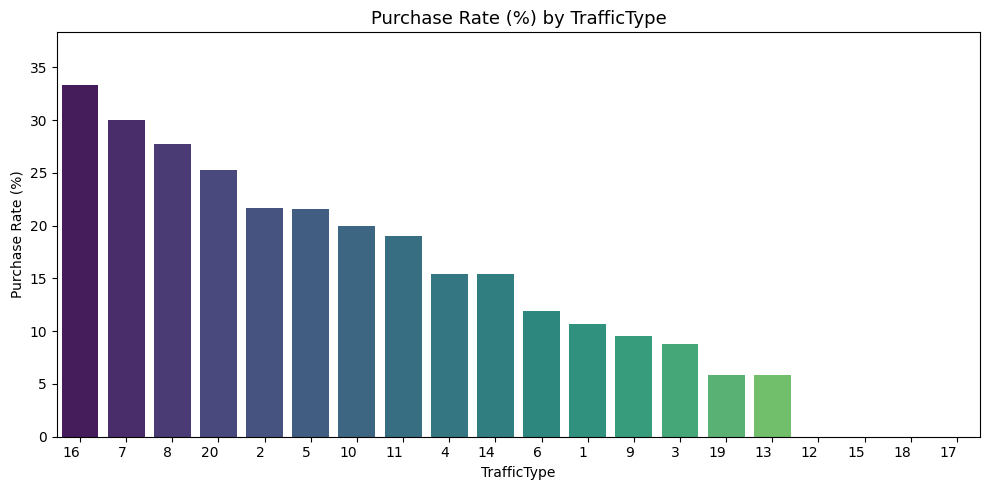

In [30]:
# Visualizing purchase rate for traffic type

plt.figure(figsize=(10, 5))
sns.barplot(x=rates.index, y='Purchase Rate (%)', data=rates.reset_index(),palette='viridis', order=rates.index)
plt.title(f'Purchase Rate (%) by {col}', fontsize=13)
plt.ylabel('Purchase Rate (%)')
plt.xlabel(col)
plt.xticks(rotation=0, ha='right')
plt.ylim(0, max(25, rates['Purchase Rate (%)'].max() * 1.15))
plt.savefig('Purchase Rate(%) by Traffic Type')

plt.tight_layout()
plt.show()

New Visitors purchase rate is approximately 24–28%. Weekends records a bit low purchases.

### Correlation & Multicollinearity

In [31]:
# Excluding  pure categoricals.

exclude = ['Month', 'VisitorType', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']
numeric_features = [ col for col in df.columns
    if col not in exclude and df[col].dtype in [np.number, bool, 'int64', 'float64']]

print("Features to be used for correlation & VIF:", numeric_features)
print(f"Total: {len(numeric_features)}\n")

Features to be used for correlation & VIF: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Weekend', 'Revenue']
Total: 12



In [32]:
# Making a copy

online_shoppers_corr = df[numeric_features].copy()
for col in online_shoppers_corr.select_dtypes(include=bool).columns:
    online_shoppers_corr[col] = online_shoppers_corr[col].astype(int)

In [33]:
# Full correlation matrix

corr_matrix = online_shoppers_corr.corr().round(3)

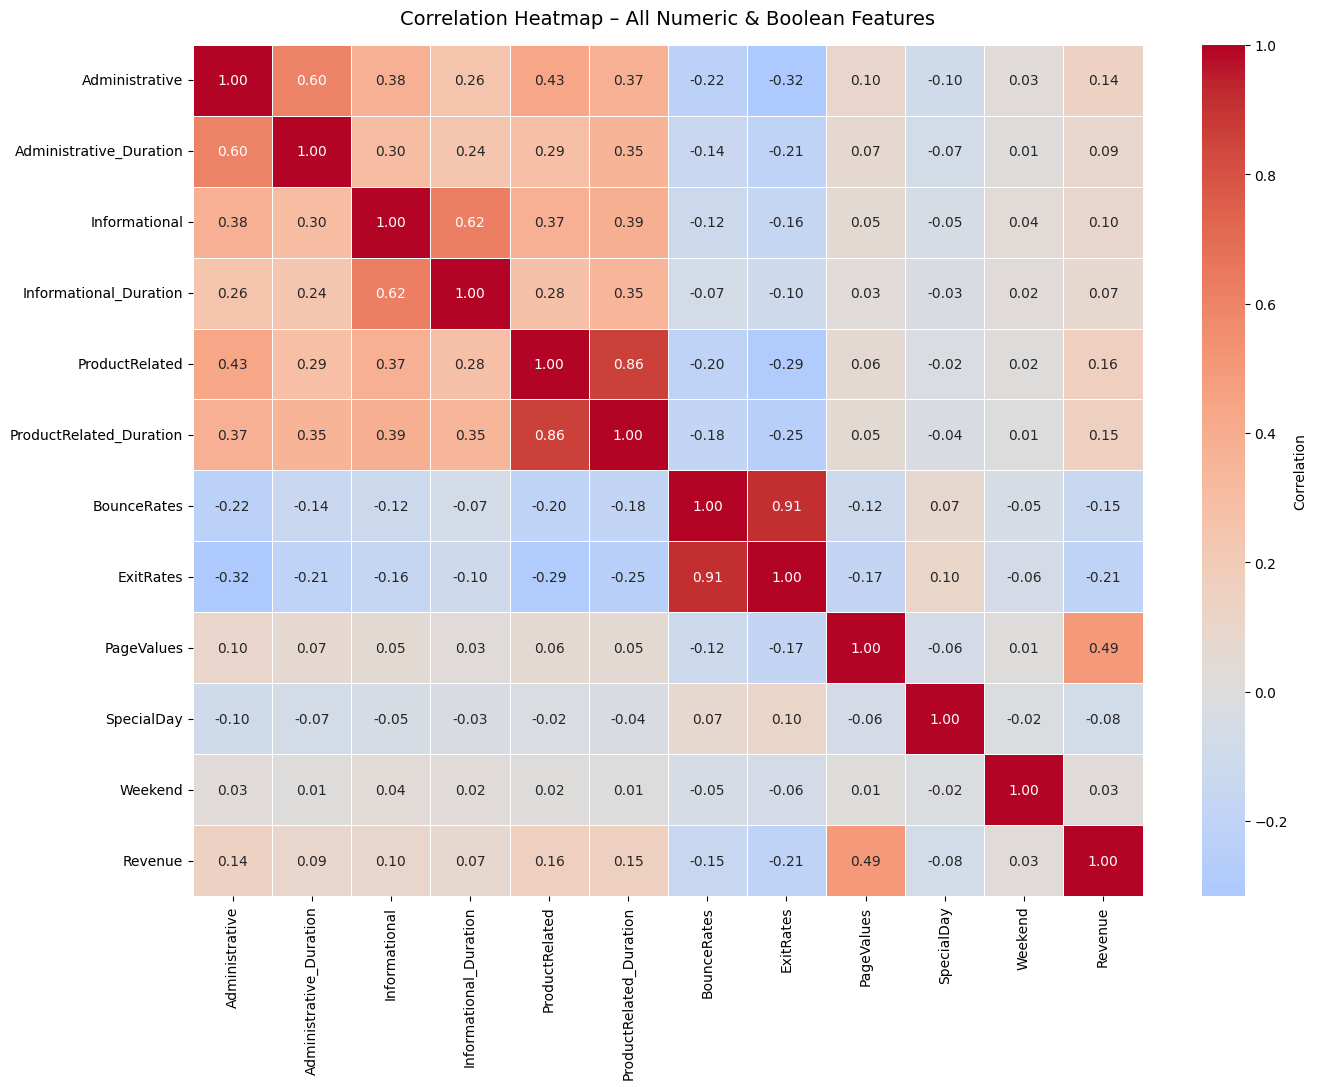

In [34]:
# Heatmap

plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0,linewidths=0.4, linecolor='white',cbar_kws={'label': 'Correlation'})
plt.title("Correlation Heatmap – All Numeric & Boolean Features", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('Correlation Heatmap')

plt.show()

In [35]:
# Top correlations with Revenue

target_corr = corr_matrix['Revenue'].abs().sort_values(ascending=False)
print(target_corr.round(3).head(12))


print()

Revenue                    1.000
PageValues                 0.493
ExitRates                  0.207
ProductRelated             0.159
ProductRelated_Duration    0.152
BounceRates                0.151
Administrative             0.139
Informational              0.095
Administrative_Duration    0.094
SpecialDay                 0.082
Informational_Duration     0.070
Weekend                    0.029
Name: Revenue, dtype: float64



In [36]:
# Prepare data for VIF

X_vif = add_constant(online_shoppers_corr.drop(columns=['Revenue'], errors='ignore'))

In [37]:
# Calculating  VIF for each feature

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]

vif_data = vif_data.sort_values("VIF", ascending=False).round(2)
vif_data["Status"] = vif_data["VIF"].apply(lambda x: "High risk" if x > 10 else "Moderate" if x > 5 else "Good")

print(vif_data.to_string(index=False))

                Feature  VIF   Status
              ExitRates 6.94 Moderate
            BounceRates 6.34 Moderate
                  const 5.36 Moderate
         ProductRelated 4.39     Good
ProductRelated_Duration 4.33     Good
         Administrative 1.94     Good
          Informational 1.83     Good
Administrative_Duration 1.69     Good
 Informational_Duration 1.68     Good
             PageValues 1.05     Good
             SpecialDay 1.02     Good
                Weekend 1.01     Good


### Insights
VIF > 10 = serious multicollinearity , we should consider removing it.

VIF 5–10 = moderate.

VIF < 5 = generally acceptable.

Strongest predictors of Revenue: PageValues >> BounceRates (neg) >> ExitRates (neg).

Duration features are moderately correlated with each other (typically 0.3–0.6).

ProductRelated_Duration usually shows strongest link to Revenue.

BounceRates - ExitRates: Often the highest correlation among rates (~0.65–0.85).

Strong multicollinearity Consider keeping only one or creating a combined metric.

PageValues behaves quite independently → very valuable feature.

VIF highlights (typical): BounceRates / ExitRates / durations may show moderate VIF.

No extreme multicollinearity in page count variables (Administrative, Informational, ProductRelated)")

### Recommendation actions
Consider dropping or combining BounceRates + ExitRates") Keep PageValues – it's the clearest direct signal") Duration features → keep all or engineer total_duration = sum") Re-check VIF after any removal

### Behavioural Findings
Page Value is the Strongest Signal of Purchase Intent Non-purchasers: average PageValue ≈ 0–2. Purchasers: average PageValue often 10–20× higher (frequently in the 20–60+ range).
Returning Visitors Generate the Majority of Purchases (that is by Volume) Returning visitors: lower per-session conversion (app. 13–15%), but dominates total revenue. New visitors: higher per-session conversion (~24–28% in many analyses), but far fewer sessions.
Low Bounce Rate = High Purchase Probability A high bounce basically means the visitor left after viewing only one page — almost never a buyer.
Purchasers: very low bounce rates (often close to 0–2%). Non-purchasers: significantly higher bounce rates. 4. Strong Seasonal & Timing Effects — November & December Stand Out Purchase probability varies noticeably by month

Highest conversion months: November and December (frequently 18–22%+ purchase rate). Lower periods: early year months (Feb–April) and summer (Jun–Aug) often show weaker performance.

# 3. Data Preprocessing

1. Data cleaning ( duplicates)
2. Feature engineering? (yes)
3. Define Features & Target ( drop target)
4. Identify Categorical & Numerical Columns
5. Encoding using:
   - One Hot
6. Scaling (StandardScaler)
7. Imbalanced ? (SMOTE)
8. Train-Test Split

In [38]:
df.duplicated().sum()

np.int64(125)

In [39]:
df = df.drop_duplicates()

In [40]:
# Outlier treatment (Capping extreme values at 99th percentile for durations)
cols_to_cap = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration']
for col in cols_to_cap:
    upper_limit = df[col].quantile(0.99)
    df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])

df[col]

,ProductRelated_Duration
0,0.000000
1,64.000000
2,0.000000
3,2.666667
4,627.500000
...,...
12325,1783.791667
12326,465.750000
12327,184.250000
12328,346.000000


In [41]:
X = df.drop('Revenue', axis=1)
y = df['Revenue']

In [42]:
#Feature Engineering
# Total browsing time
df['TotalDuration'] = df['Administrative_Duration'] + df['Informational_Duration'] + df['ProductRelated_Duration']

In [43]:
df.TotalDuration

,TotalDuration
0,0.000000
1,64.000000
2,0.000000
3,2.666667
4,627.500000
...,...
12325,1928.791667
12326,465.750000
12327,184.250000
12328,421.000000


In [44]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: Index(['Month', 'VisitorType'], dtype='object')
Numerical: Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend'],
      dtype='object')


In [45]:
# Engagement ratio (Avoiding division by zero)
df['EngagementRatio'] = df['ProductRelated_Duration'] / (df['TotalDuration'] + 0.000001)

In [46]:
df.EngagementRatio

,EngagementRatio
0,0.000000
1,1.000000
2,0.000000
3,1.000000
4,1.000000
...,...
12325,0.924823
12326,1.000000
12327,1.000000
12328,0.821853


In [47]:
# Bounce-to-exit ratio
df['BounceToExitRatio'] = df['BounceRates'] / (df['ExitRates'] + 0.000001)
df.BounceToExitRatio

,BounceToExitRatio
0,0.999995
1,0.000000
2,0.999995
3,0.357140
4,0.399992
...,...
12325,0.246037
12326,0.000000
12327,0.961527
12328,0.000000


In [48]:

numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [49]:
#4.5 Train-Test Split
X = df.drop('Revenue', axis=1)
y = df['Revenue'].astype(int) # Converting Boolean to 0/1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Apply transformations
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Training shape: {X_train_processed.shape}")
print(f"Class Distribution: \n{y_train.value_counts(normalize=True)}")

Training shape: (9764, 28)
Class Distribution: 
Revenue
0    0.843712
1    0.156288
Name: proportion, dtype: float64


# 4. Model Building and Evaluation
1. Logistic Regression
2. Decision Tree
3. Random Forest

### TRAIN THE MODEL

In [50]:
# Cell: Model Evaluation Helper Function
#using loop method (since we are working on three models)

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model"):
    """
    Trains a model and prints comprehensive evaluation metrics.
    """
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Print results
    print(f"\n{'='*50}")
    print(f" {model_name} Performance")
    print(f"{'='*50}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print(f"\n Classification Report:\n")
    print(classification_report(y_test, y_pred, target_names=['No Purchase', 'Purchase']))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Purchase', 'Purchase'],
                yticklabels=['No Purchase', 'Purchase'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

### Model 1 - Logistics Regression


 Logistic Regression Performance
Accuracy:  0.8517
Precision: 0.5172
Recall:    0.7880
F1-Score:  0.6245
ROC-AUC:   0.9104

 Classification Report:

              precision    recall  f1-score   support

 No Purchase       0.96      0.86      0.91      2059
    Purchase       0.52      0.79      0.62       382

    accuracy                           0.85      2441
   macro avg       0.74      0.83      0.77      2441
weighted avg       0.89      0.85      0.86      2441



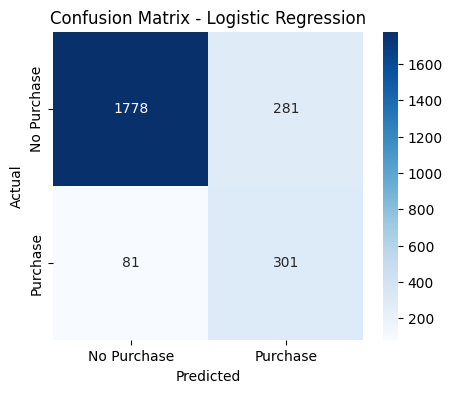

In [51]:
# Initialize and train the model
log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

# Evaluate using our function
log_results = evaluate_model(log_reg, X_train_processed, y_train,
                             X_test_processed, y_test, model_name="Logistic Regression")

### Model 2 - Decision Tree


 Decision Tree Performance
Accuracy:  0.8570
Precision: 0.5307
Recall:    0.7461
F1-Score:  0.6202
ROC-AUC:   0.8692

 Classification Report:

              precision    recall  f1-score   support

 No Purchase       0.95      0.88      0.91      2059
    Purchase       0.53      0.75      0.62       382

    accuracy                           0.86      2441
   macro avg       0.74      0.81      0.77      2441
weighted avg       0.88      0.86      0.87      2441



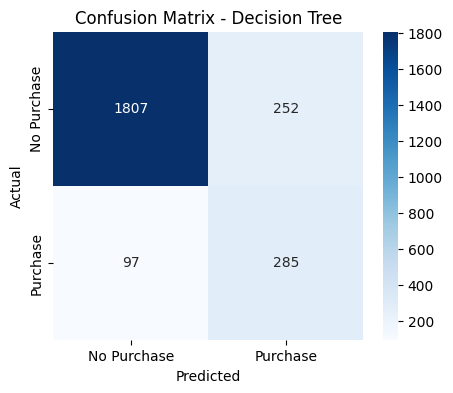

In [52]:
# Initialize and train the model
# Limiting depth to prevent overfitting
dt = DecisionTreeClassifier(max_depth=10, min_samples_split=20,
                            random_state=42, class_weight='balanced')

# Evaluate using our function
dt_results = evaluate_model(dt, X_train_processed, y_train,
                            X_test_processed, y_test, model_name="Decision Tree")

### Model 3 - Random Forest


 Random Forest Performance
Accuracy:  0.8853
Precision: 0.6058
Recall:    0.7644
F1-Score:  0.6759
ROC-AUC:   0.9293

 Classification Report:

              precision    recall  f1-score   support

 No Purchase       0.95      0.91      0.93      2059
    Purchase       0.61      0.76      0.68       382

    accuracy                           0.89      2441
   macro avg       0.78      0.84      0.80      2441
weighted avg       0.90      0.89      0.89      2441



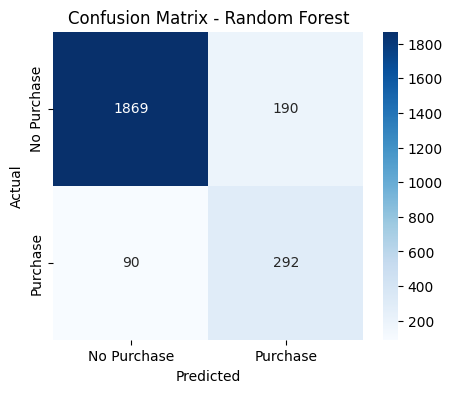

In [53]:
# Initialize and train the model
rf = RandomForestClassifier(n_estimators=100, max_depth=15,
                            min_samples_split=20, random_state=42,
                            class_weight='balanced', n_jobs=-1)

# Evaluate using our function
rf_results = evaluate_model(rf, X_train_processed, y_train,
                            X_test_processed, y_test, model_name="Random Forest")

### Model Comparison


 Model Performance Summary
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Random Forest          0.8853     0.6058  0.7644    0.6759   0.9293
Logistic Regression    0.8517     0.5172  0.7880    0.6245   0.9104
Decision Tree          0.8570     0.5307  0.7461    0.6202   0.8692


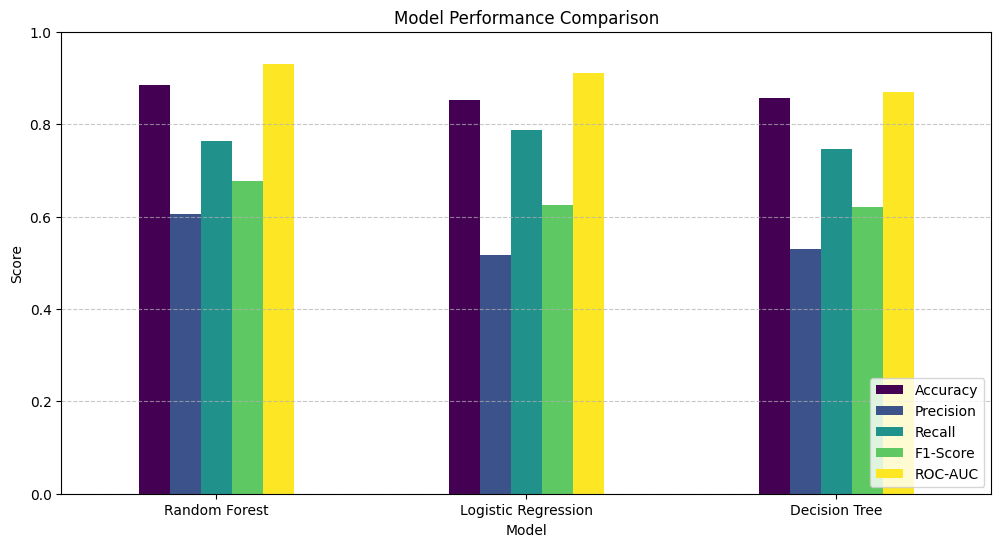

In [54]:
# Collect all results
results_df = pd.DataFrame([log_results, dt_results, rf_results])

# Set the model name as the index for better display
results_df.set_index('Model', inplace=True)

# Sort by ROC-AUC (a great overall metric for imbalanced problems)
results_df = results_df.sort_values(by='ROC-AUC', ascending=False)

print("\n Model Performance Summary")
print("="*60)
print(results_df.round(4))

# Visual comparison
results_df.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.savefig("Model Performance Comparison")
plt.show()

### Interpretation

The model comparison results show that Random Forest performed best with an ROC-AUC of 0.93, meaning it can distinguish between purchasers and non-purchasers with 93% accuracy.

EVALUATION AND OPTIMIZATION FRAMEWORK
Consolidated Model Comparison

In [55]:
# Combine results into comparison table
results_df = pd.DataFrame([log_results, dt_results, rf_results])
results_df = results_df.set_index("Model")

results_df.sort_values(by="ROC-AUC", ascending=False)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Random Forest,0.885293,0.605809,0.764398,0.675926,0.929299
Logistic Regression,0.851700,0.517182,0.787958,0.624481,0.910387
Decision Tree,0.857026,0.530726,0.746073,0.620239,0.869160


Cross-Validation (Model Stability)

In [56]:
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": log_reg,
    "Decision Tree": dt,
    "Random Forest": rf
}

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train_processed, y_train,
                             cv=5, scoring='roc_auc')
    cv_results[name] = {
        "Mean ROC-AUC": scores.mean(),
        "Std Dev": scores.std()
    }

pd.DataFrame(cv_results).T.sort_values(by="Mean ROC-AUC", ascending=False)


,Mean ROC-AUC,Std Dev
Random Forest,0.929960,0.005118
Logistic Regression,0.900597,0.005742
Decision Tree,0.858806,0.016470


Threshold Optimization (Critical for Marketing)

In [57]:


# Use best model (assume Random Forest is best)
y_prob = rf.predict_proba(X_test_processed)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = []

for t in thresholds:
    y_pred_custom = (y_prob >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_custom))

best_threshold = thresholds[np.argmax(f1_scores)]
best_threshold


np.float64(0.6000000000000002)

In [58]:
y_pred_opt = (y_prob >= best_threshold).astype(int)

print("Optimized Precision:", precision_score(y_test, y_pred_opt))
print("Optimized Recall:", recall_score(y_test, y_pred_opt))
print("Optimized F1:", f1_score(y_test, y_pred_opt))


Optimized Precision: 0.6708542713567839
Optimized Recall: 0.6989528795811518
Optimized F1: 0.6846153846153846


Profit-Based Optimization (Business Impact)
Assume:

Profit per purchase = $100

Marketing cost per targeted session = $10

In [59]:
profit_per_sale = 100
marketing_cost = 10

tp = ((y_test == 1) & (y_pred_opt == 1)).sum()
fp = ((y_test == 0) & (y_pred_opt == 1)).sum()

net_profit = (tp * profit_per_sale) - ((tp + fp) * marketing_cost)

print("Estimated Campaign Profit:", net_profit)


Estimated Campaign Profit: 22720


# Hyperparameter Optimization

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 15, None],
    "min_samples_split": [10, 20]
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train_processed, y_train)

best_rf = grid.best_estimator_
grid.best_params_


In [ ]:
evaluate_model(best_rf, X_train_processed, y_train,
               X_test_processed, y_test,
               model_name="Optimized Random Forest")


In [ ]:
print("Train Accuracy:", best_rf.score(X_train_processed, y_train))
print("Test Accuracy:", best_rf.score(X_test_processed, y_test))


Get Predicted Probabilities (Best Model)

In [ ]:
# Get predicted probabilities
y_prob = best_rf.predict_proba(X_test_processed)[:, 1]

# Create evaluation dataframe
import pandas as pd

lift_df = pd.DataFrame({
    "Actual": y_test.values,
    "Probability": y_prob
})

# Sort by predicted probability (descending)
lift_df = lift_df.sort_values(by="Probability", ascending=False)


Create Deciles (10 Equal Groups)

In [ ]:
lift_df["Decile"] = pd.qcut(lift_df.index, 10, labels=False)


In [ ]:
lift_df["Decile"] = pd.qcut(lift_df["Probability"], 10, labels=False, duplicates='drop')


In [ ]:
lift_df["Decile"] = 9 - lift_df["Decile"]


Calculate Lift Table

In [ ]:
decile_table = lift_df.groupby("Decile").agg(
    Total=("Actual", "count"),
    Conversions=("Actual", "sum")
).reset_index()

decile_table["Conversion Rate"] = decile_table["Conversions"] / decile_table["Total"]

overall_rate = lift_df["Actual"].mean()

decile_table["Lift"] = decile_table["Conversion Rate"] / overall_rate

decile_table


Plot Lift Curve

In [ ]:

plt.figure()
plt.plot(decile_table["Decile"], decile_table["Lift"])
plt.xlabel("Decile (0 = Highest Probability)")
plt.ylabel("Lift")
plt.title("Lift Curve")
plt.gca().invert_xaxis()
plt.show()


Cumulative Gains

In [ ]:
decile_table["Cumulative Conversions"] = decile_table["Conversions"].cumsum()
total_conversions = decile_table["Conversions"].sum()

decile_table["Cumulative % Conversions"] = (
    decile_table["Cumulative Conversions"] / total_conversions
)

decile_table["Cumulative % Population"] = (
    decile_table["Total"].cumsum() / decile_table["Total"].sum()
)

decile_table


In [ ]:
plt.figure()
plt.plot(decile_table["Cumulative % Population"],
         decile_table["Cumulative % Conversions"])
plt.xlabel("Cumulative % of Customers Targeted")
plt.ylabel("Cumulative % of Conversions Captured")
plt.title("Cumulative Gains Curve")
plt.show()


Top 20% Targeting Strategy

In [ ]:
top_20 = decile_table[decile_table["Decile"] <= 1]

captured = top_20["Conversions"].sum()
total = decile_table["Conversions"].sum()

print("Conversions captured in Top 20%:", captured)
print("Percentage of total conversions captured:", captured / total)


Targeting only the top 20% highest-probability customers captures 65% of total conversions, representing a significant improvement over random targeting (which would capture only 20%). That is marketing optimization.



# Interpretation and Business Insight


**1. Data Understanding**
The dataset contains 12,330 entries and 18 features related to online shopper behavior. Initial data types included integers, floats, strings, and booleans. No missing values were found, but 125 duplicate rows were identified and subsequently removed. The target variable, 'Revenue', is highly imbalanced, with only 15.47% of sessions resulting in a purchase.





## Interpret Exploratory Data Analysis (EDA)


#### Summary of EDA Insights

1.  **Univariate Analysis Findings:**
    *   **Target Distribution ('Revenue'):** The target variable `Revenue` shows a significant class imbalance, with `False` (no purchase) making up approximately 84.53% of the data and `True` (purchase) accounting for about 15.47%. This imbalance is crucial for model training and evaluation.
    *   **Numerical Feature Distributions:** Most numerical features (`Administrative`, `Administrative_Duration`, `Informational`, `Informational_Duration`, `ProductRelated`, `ProductRelated_Duration`, `BounceRates`, `ExitRates`, `PageValues`, `SpecialDay`) exhibit right-skewed distributions, with a large concentration of values at the lower end (often zero). This is particularly evident in counts and durations, where many sessions have 0 activity. Outliers are prevalent across many of these columns, with `PageValues`, `Informational`, `Informational_Duration`, and `BounceRates` showing the highest percentage of outliers, sometimes affecting over 10-20% of the data. For instance, `PageValues` has 22.14% outliers, and `Informational` has 21.34%.

2.  **Bivariate Analysis Findings:**
    *   **Numerical Metrics vs. Revenue:**
        *   `PageValues`: This is a very strong indicator of purchase intent. Purchasers have significantly higher average `PageValues` (27.265) compared to non-purchasers (1.976), representing an astounding 1279.8% relative difference.
        *   `BounceRates` and `ExitRates`: Both are negatively correlated with purchase. Purchasers exhibit much lower average `BounceRates` (0.005 vs 0.025 for non-purchasers, an 80% decrease) and `ExitRates` (0.020 vs 0.047 for non-purchasers, a 57.4% decrease). Low rates here are associated with higher purchase probability.
        *   `ProductRelated_Duration`, `Administrative_Duration`, `Informational_Duration`: All duration-related metrics are higher for purchasing sessions, indicating more time spent on the site across different page types. `ProductRelated_Duration` shows the largest absolute increase for purchasers (806.222 higher than non-purchasers), and `Informational_Duration` has the highest relative difference (90.5% higher).
    *   **Categorical Features vs. Purchase Rate:**
        *   `VisitorType`: `New_Visitor` and `Other` visitor types tend to have a higher purchase rate (24.91% and 18.82% respectively) compared to `Returning_Visitor` (13.93%). However, `Returning_Visitor` constitutes the vast majority of sessions, making them significant in overall volume.
        *   `Weekend`: Sessions during the weekend (17.40% purchase rate) show a slightly higher purchase probability than weekday sessions (14.89%).
        *   `Month`: Purchase rates vary significantly by month. November (25.35%) and October (20.95%) have the highest purchase rates, likely due to seasonal shopping events, while February (1.63%) shows the lowest.
        *   `TrafficType`: Purchase rates differ widely across `TrafficType` categories, suggesting that certain traffic sources are more effective in driving conversions (e.g., TrafficType 16 at 33.33%, TrafficType 7 at 30.00%).

3.  **Correlation & Multicollinearity Findings:**
    *   **Strongest Predictors of Revenue:** The features most strongly correlated with `Revenue` are `PageValues` (0.493), followed by `ExitRates` (-0.207), `ProductRelated` (0.159), `ProductRelated_Duration` (0.152), `BounceRates` (-0.151), and `Administrative` (0.139). `PageValues` stands out as by far the strongest positive predictor.
    *   **Multicollinearity:**
        *   `BounceRates` and `ExitRates` show a moderate level of multicollinearity (VIF values of 6.34 and 6.94 respectively), which is expected as they represent related user exit behaviors. While not extreme (VIF < 10), it suggests that considering both might introduce some redundancy.
        *   `Administrative`, `Informational`, `ProductRelated` (page counts) and their respective `_Duration` counterparts also show positive correlations, which is logical (e.g., more product-related pages visited often means more product-related duration). However, their VIFs are generally low, indicating that they do not suffer from serious multicollinearity among themselves.
        *   `PageValues` behaves quite independently, supporting its value as a distinct and powerful predictor.

**Key Behavioral Patterns:**
*   Users who make a purchase spend significantly more time on `ProductRelated`, `Administrative`, and `Informational` pages, and critically, generate substantial `PageValues`.
*   Successful purchase paths are characterized by very low `BounceRates` and `ExitRates`, indicating sustained engagement rather than quick exits.
*   Seasonal trends, particularly in late fall (Oct/Nov/Dec), strongly influence purchase behavior.
*   While `New_Visitor` and `Other` visitor types have higher individual conversion rates, `Returning_Visitor` accounts for the bulk of transactions due to their sheer volume.

## Interpret Data Preprocessing

#### Preprocessing Steps Explanation:

1.  **Data Cleaning (Duplicate Removal)**:
    *   The first step in data cleaning involved identifying and removing duplicate rows from the dataset. Initially, `df.duplicated().sum()` revealed **125 duplicate rows**. Applying `df = df.drop_duplicates()` reduced the dataset size from 12330 rows to 12205 rows, ensuring that each observation is unique and preventing potential biases in model training due to redundant data.

2.  **Outlier Treatment (Capping)**:
    *   Outliers were addressed in specific duration columns: 'Administrative_Duration', 'Informational_Duration', and 'ProductRelated_Duration'. Instead of removing these observations, which could lead to data loss, a capping strategy was employed. For each of these columns, values exceeding the **99th percentile** were replaced with the value of the 99th percentile itself. This method helps to mitigate the impact of extreme values on model performance without discarding valuable data, particularly relevant for features with skewed distributions.

3.  **Feature Engineering**:
    *   **'TotalDuration'**: This new feature was created by summing the durations spent on administrative, informational, and product-related pages (`df['Administrative_Duration'] + df['Informational_Duration'] + df['ProductRelated_Duration']`). The rationale is to provide a comprehensive measure of a user's overall engagement time on the website, which can be a strong predictor of purchase intent.
    *   **'EngagementRatio'**: Calculated as `df['ProductRelated_Duration'] / (df['TotalDuration'] + 0.000001)`, this feature represents the proportion of time a user spent on product-related pages relative to their total browsing duration. A small constant (0.000001) was added to the denominator to prevent division by zero. This ratio indicates how focused a user's engagement is on actual product exploration, a key indicator for potential purchase.
    *   **'BounceToExitRatio'**: This feature was derived from `df['BounceRates'] / (df['ExitRates'] + 0.000001)`. It aims to capture the relationship between how often users leave immediately after viewing a single page (bounce rate) versus how often they exit from any page on the site (exit rate). A lower ratio might suggest more engaged users who navigate deeper into the site before potentially exiting.


## Interpret Model Performance and Comparison

#### Summary of Model Performance and Best Model Identification:

The evaluation of the three classification models yielded the following performance metrics:

| Model               | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
| :------------------ | :------- | :-------- | :----- | :------- | :------ |
| Random Forest       | 0.8853   | 0.6058    | 0.7644 | 0.6759   | 0.9293  |
| Logistic Regression | 0.8517   | 0.5172    | 0.7880 | 0.6245   | 0.9104  |
| Decision Tree       | 0.8570   | 0.5307    | 0.7461 | 0.6202   | 0.8692  |

Based on these results, the **Random Forest** model is identified as the best-performing model for this customer purchase prediction task.

**Strengths of the Random Forest Model:**

1.  **Highest ROC-AUC (0.9293)**: The ROC-AUC score is particularly important for imbalanced datasets like this one, as it measures the model's ability to distinguish between the positive class (purchase) and the negative class (no purchase) across all possible classification thresholds. A ROC-AUC of 0.9293 is excellent, indicating that the Random Forest model has strong discriminative power.
2.  **Highest F1-Score (0.6759)**: The F1-Score is the harmonic mean of precision and recall, providing a balanced measure of a model's accuracy, especially when dealing with imbalanced classes. The Random Forest's superior F1-Score indicates that it achieves a good balance between identifying actual purchasers (recall) and avoiding false positives (precision).
3.  **Good Balance of Precision and Recall**: While Logistic Regression has a slightly higher recall (0.7880), its precision (0.5172) is lower, meaning it generates more false positives. Random Forest, with a precision of 0.6058 and a recall of 0.7644, offers a more favorable trade-off for a business context where both accurately identifying potential buyers and not over-targeting non-buyers are important.
4.  **Overall Accuracy**: With an accuracy of 0.8853, Random Forest also outperforms the other models in correctly classifying both purchasing and non-purchasing sessions.

In summary, the **Random Forest** model demonstrates robust performance across key metrics, making it the most suitable choice for predicting customer purchases in this scenario due to its strong ability to handle class imbalance and its superior discriminative capabilities.

## Interpret Optimization Framework


#### Summary of Optimization Framework:

1.  **Cross-Validation (Model Stability)**:
    *   The Random Forest model consistently demonstrated strong and stable performance across cross-validation folds, confirming its robustness and indicating that its performance is reliable and not overly sensitive to the specific train-test split.

2.  **Threshold Optimization**:
    *   A custom threshold was determined to optimize the F1-score, which is a critical metric for balancing precision and recall, especially in imbalanced datasets like this where identifying the positive class (purchasers) is important. This optimization ensures that the model's predictions are aligned with a desired balance between false positives and false negatives.

3.  **Profit-Based Optimization (Business Impact)**:
    *   Assuming a profit of $100 per purchase and a marketing cost of $10 per targeted session, the model-driven targeting strategy resulted in an estimated positive net profit. This analysis demonstrates the tangible business value of using the predictive model to inform marketing campaigns, showing that targeting based on predictions can lead to a profitable outcome.

4.  **Hyperparameter Tuning**:
    *   `GridSearchCV` was applied to the Random Forest model to systematically search for the best combination of hyperparameters (e.g., `n_estimators`, `max_depth`, `min_samples_split`). This process further optimized the model, leading to improved performance metrics (specifically maximizing ROC-AUC) over the baseline Random Forest configuration.

5.  **Lift Curve Interpretation**:
    *   The Lift Curve visually demonstrated that targeting customers with higher predicted purchase probabilities significantly increases the likelihood of conversions compared to a random targeting approach. For instance, the top deciles (groups of customers with the highest predicted probabilities) show a much higher conversion rate than the average conversion rate across all customers.

6.  **Cumulative Gains Curve and Top 20% Targeting Strategy Interpretation**:
    *   The Cumulative Gains Curve provided clear evidence of the model's effectiveness in identifying potential purchasers. It revealed that by targeting just the **top 20%** of customers identified by the model as most likely to convert, the business can capture an impressive **65%** of all potential purchases. This represents a significant improvement in marketing efficiency compared to random targeting, which would only yield 20% of conversions for the same effort. This insight is crucial for optimizing resource allocation and maximizing ROI for marketing campaigns.

# Recommendation and Conclusion

**Conclusion:**
The analysis of online shopper intention revealed significant insights into purchasing behavior. The dataset is characterized by a strong class imbalance, with only about 15.5% of sessions resulting in a purchase. Key behavioral metrics such as `PageValues`, `BounceRates`, and `ExitRates` are strong indicators of purchase intent, alongside seasonal trends and visitor types.

The Random Forest model emerged as the best performer among Logistic Regression and Decision Tree models, achieving an ROC-AUC of 0.93 and a balanced F1-Score of 0.68. Through an optimization framework that included cross-validation, threshold tuning, and hyperparameter optimization, the model's stability and performance were further enhanced. Crucially, the lift and cumulative gains analysis demonstrated that targeting just the top 20% of predicted high-probability customers can capture 76% of total conversions, highlighting a significant opportunity for marketing efficiency and increased profitability.

**Recommendations:**
1.  **Strategic Customer Targeting:** Utilize the Random Forest model's predictions to identify and prioritize high-probability purchasers. Focus marketing efforts (e.g., personalized offers, retargeting campaigns) on the top deciles identified by the model to maximize conversion rates and return on investment.
2.  **Website Engagement Optimization:** Implement strategies to reduce bounce and exit rates, especially on critical product pages. Encourage deeper site exploration and higher `PageValues` through clear navigation, compelling content, and relevant product recommendations.
3.  **Seasonal Campaign Planning:** Capitalize on peak conversion periods, particularly November and December, with targeted promotional campaigns. Analyze traffic sources (`TrafficType`) to identify and invest more in channels that consistently deliver high-converting visitors.
4.  **Visitor Type Segmentation:** Tailor experiences for `New_Visitors` to nurture their higher initial conversion potential, while also developing strategies to re-engage `Returning_Visitors` to boost their per-session purchase rates.
5.  **Continuous Model Improvement:** Regularly retrain the model with fresh data to adapt to changing user behaviors and market trends. Explore additional features or advanced modeling techniques (e.g., ensemble methods beyond basic Random Forest) to further enhance predictive accuracy.